# 05 — Random-graph baseline & small-world (Course topics L6 + L7)

**Semiconductor Supply Chain — Network Analysis**

Is the supply network "small-world" — short paths *and* high local clustering?
We measure clustering **C** and average path length **L** on the giant component
and compare them against an **Erdős–Rényi (ER)** random graph with the same
number of nodes and edges.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'scripts' / 'analysis.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'scripts'))

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import analysis

U = analysis.company_supply_undirected()
G = analysis.giant_component(U)
n, m = G.number_of_nodes(), G.number_of_edges()
C_real = nx.average_clustering(G)
L_real = nx.average_shortest_path_length(G)
print(f'n={n}, m={m}')
print(f'REAL  clustering C={C_real:.3f}  avg path L={L_real:.3f}')

n=108, m=1256
REAL  clustering C=0.086  avg path L=1.991


## 1. Erdős–Rényi ensemble (same n, m)

We average over 50 random graphs to get stable baselines C_ER and L_ER.

In [2]:
rng = np.random.default_rng(42)
Cs, Ls = [], []
for _ in range(50):
    R = nx.gnm_random_graph(n, m, seed=int(rng.integers(1e9)))
    if not nx.is_connected(R):
        R = R.subgraph(max(nx.connected_components(R), key=len)).copy()
    Cs.append(nx.average_clustering(R))
    Ls.append(nx.average_shortest_path_length(R))
C_er, L_er = float(np.mean(Cs)), float(np.mean(Ls))
print(f'ER    clustering C={C_er:.3f}  avg path L={L_er:.3f}')

ER    clustering C=0.217  avg path L=1.787


## 2. Small-world coefficient σ

σ = (C/C_ER) / (L/L_ER). σ > 1 (clustering boosted, path length comparable)
signals small-world. σ < 1 means clustering is *below* random.

In [3]:
sigma = (C_real / C_er) / (L_real / L_er)
print(f'C_real / C_ER = {C_real / C_er:.2f}')
print(f'L_real / L_ER = {L_real / L_er:.2f}')
print(f'small-world sigma = {sigma:.2f}')

C_real / C_ER = 0.40
L_real / L_ER = 1.11
small-world sigma = 0.36


## 3. Visualise

saved C:\Users\Max\Desktop\project\reports\figures\05_models_comparison.png


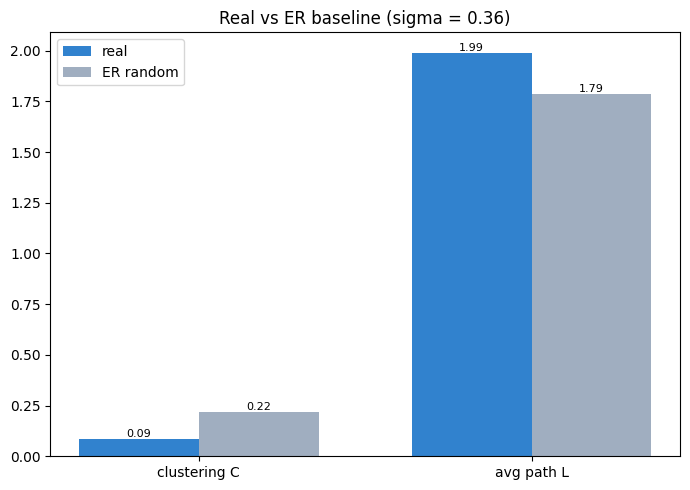

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(2)
ax.bar(x - 0.18, [C_real, L_real], width=0.36, label='real', color='#3182ce')
ax.bar(x + 0.18, [C_er, L_er], width=0.36, label='ER random', color='#a0aec0')
ax.set_xticks(x); ax.set_xticklabels(['clustering C', 'avg path L'])
ax.set_title(f'Real vs ER baseline (sigma = {sigma:.2f})'); ax.legend()
for xi, (a, b) in enumerate(zip([C_real, L_real], [C_er, L_er])):
    ax.text(xi - 0.18, a, f'{a:.2f}', ha='center', va='bottom', fontsize=8)
    ax.text(xi + 0.18, b, f'{b:.2f}', ha='center', va='bottom', fontsize=8)
fig.tight_layout()
out = analysis.FIGURES / '05_models_comparison.png'
fig.savefig(out, dpi=130, bbox_inches='tight'); print('saved', out); plt.show()

## 4. Takeaways

- **Paths are short** (L ≈ 2) — any firm reaches any other in ~two supply hops,
  as in a small-world (and the dense ER graph is similar).
- But **clustering is *below* random** (C_real < C_ER, σ ≈ 0.4), so the network is
  **not** a classic small-world. The reason is structural: the chain is nearly
  **multipartite** (equipment→fab→fabless...), and a firm's suppliers rarely
  supply *each other*, which suppresses triangles.
- Lesson: short paths come from a few high-degree hubs bridging tiers, not from
  tight local neighbourhoods. This sets up the scale-free test next.

**Next:** `06_scale_free.ipynb` — is the degree distribution a power law?